# Hei Njål
# ***I LOVE COCK***

In [121]:
print('U lost bbygurl?')

U lost bbygurl?


Importing our dataset

In [122]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import seaborn as sns


df = pd.read_csv("../data/england-premier-league-matches-2018-to-2019-stats.csv")

Analyszing features

In [123]:
df.head()

odds_columns = [col for col in df.columns if 'odds' in col.lower()]
df[odds_columns].sample()
prematch_columns = [col for col in df.columns if 'pre' in col.lower() and 'match' in col.lower()]
df[prematch_columns].sample()
null_columns = [col for col in df.columns if (df[col] == 0).all()]
df[null_columns].head()
not_completed = [col for col in df.columns if (df['status'] != 'complete').any()]
print(not_completed)
percentage_columns = [col for col in df.columns if 'percentage' in col.lower()]
print(percentage_columns)

[]
['btts_percentage_pre_match', 'over_15_percentage_pre_match', 'over_25_percentage_pre_match', 'over_35_percentage_pre_match', 'over_45_percentage_pre_match', 'over_15_HT_FHG_percentage_pre_match', 'over_05_HT_FHG_percentage_pre_match', 'over_15_2HG_percentage_pre_match', 'over_05_2HG_percentage_pre_match']


Data cleaning

In [124]:

#Remove all columns in the dataset that include odds. 
df_filtered = df.drop(columns = odds_columns)
df_filtered = df_filtered.drop(columns = percentage_columns)

#The first match 2 matches of the season has no 'pre-match' content, but are valued at 0, which could mess with this feature
df_filtered.loc[df_filtered['Game Week'] <= 2, prematch_columns] = np.nan

#We dont want goal information to sneak in to our feature set and cause data leakage
df_filtered = df_filtered.drop(columns = ['total_goal_count', 'home_team_goal_count_half_time','away_team_goal_count_half_time','total_goals_at_half_time'])

# Parse date_GMT into useful features
df_filtered['match_date'] = pd.to_datetime(df_filtered['date_GMT'], errors='coerce')
df_filtered['match_month'] = df_filtered['match_date'].dt.month
df_filtered['match_day'] = df_filtered['match_date'].dt.day
df_filtered['match_weekday'] = df_filtered['match_date'].dt.weekday
df_filtered = df_filtered.drop(columns=['date_GMT', 'match_date'])

# Encode Categorical Columns
categorical_columns = ['home_team_name', 'away_team_name', 'stadium_name', 'referee']
label_encoders = {}
for col in categorical_columns:
    df_filtered[col] = df_filtered[col].fillna("Unknown")
    le = LabelEncoder()
    df_filtered[col] = le.fit_transform(df_filtered[col].astype(str))
    label_encoders[col] = le


# Drop Irrelevant or Redundant Columns
df_filtered = df_filtered.drop(columns=[
    'status', 'home_team_goal_timings', 'away_team_goal_timings', 'btts_percentage_pre_match', 'over_15_percentage_pre_match',
    'over_25_percentage_pre_match', 'over_35_percentage_pre_match', 'over_45_percentage_pre_match', 'over_15_HT_FHG_percentage_pre_match',
    'over_05_HT_FHG_percentage_pre_match', 'over_15_2HG_percentage_pre_match', 'over_05_2HG_percentage_pre_match'])

#Reordering so the target features appear first in the list
target_features = ['home_team_goal_count', 'away_team_goal_count'] 
columns = target_features + [col for col in df_filtered.columns if col not in target_features]
df_filtered = df_filtered[columns]

print(df_filtered.columns)
df_filtered.sample(5)

Index(['home_team_goal_count', 'away_team_goal_count', 'timestamp',
       'attendance', 'home_team_name', 'away_team_name', 'referee',
       'Game Week', 'Pre-Match PPG (Home)', 'Pre-Match PPG (Away)', 'home_ppg',
       'away_ppg', 'home_team_corner_count', 'away_team_corner_count',
       'home_team_yellow_cards', 'home_team_red_cards',
       'away_team_yellow_cards', 'away_team_red_cards',
       'home_team_first_half_cards', 'home_team_second_half_cards',
       'away_team_first_half_cards', 'away_team_second_half_cards',
       'home_team_shots', 'away_team_shots', 'home_team_shots_on_target',
       'away_team_shots_on_target', 'home_team_shots_off_target',
       'away_team_shots_off_target', 'home_team_fouls', 'away_team_fouls',
       'home_team_possession', 'away_team_possession',
       'Home Team Pre-Match xG', 'Away Team Pre-Match xG', 'team_a_xg',
       'team_b_xg', 'average_goals_per_match_pre_match',
       'average_corners_per_match_pre_match',
       'average_card

C:\Users\njaal\AppData\Local\Temp\ipykernel_25980\3887077574.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_filtered['match_date'] = pd.to_datetime(df_filtered['date_GMT'], errors='coerce')


,home_team_goal_count,away_team_goal_count,timestamp,attendance,home_team_name,away_team_name,referee,Game Week,Pre-Match PPG (Home),Pre-Match PPG (Away),...,Away Team Pre-Match xG,team_a_xg,team_b_xg,average_goals_per_match_pre_match,average_corners_per_match_pre_match,average_cards_per_match_pre_match,stadium_name,match_month,match_day,match_weekday
328,2,0,1555164000,21480,3,4,13,34,1.25,0.53,...,1.06,1.85,1.17,2.77,8.25,3.36,17,4,13,5
61,2,0,1538229600,60019,1,17,2,7,2.00,2.00,...,1.40,1.22,1.53,2.84,9.67,3.17,3,9,29,5
45,1,2,1537020000,52165,14,1,10,5,0.00,1.50,...,1.98,0.70,1.09,4.00,8.50,5.50,12,9,15,5
265,2,0,1550934000,52174,14,9,8,27,1.00,0.50,...,1.19,2.99,0.37,2.57,9.95,3.21,12,2,23,5
151,1,0,1544281200,59893,1,9,14,16,2.13,0.71,...,1.37,1.30,0.66,3.15,10.96,3.88,3,12,8,5


Feature Importance Testing

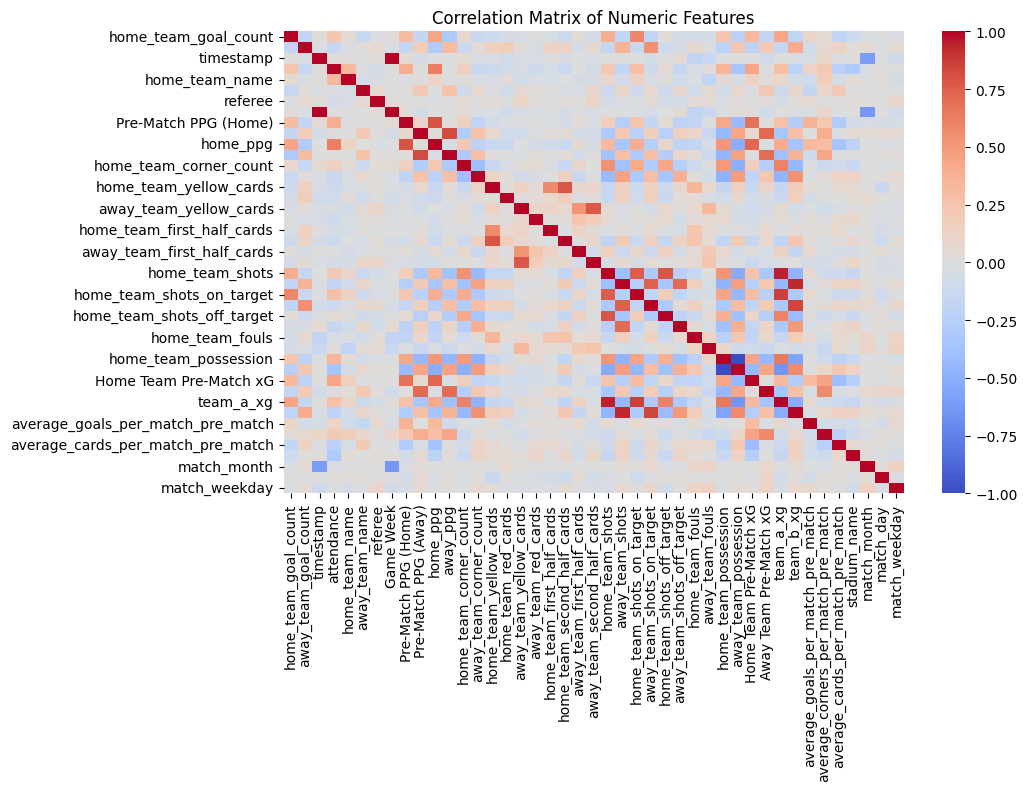

In [125]:
correlation_matrix = df_filtered.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=False, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of Numeric Features")
plt.show()

Her kan du putte in greiene om feature optimalisering sander

Så kommer vi fram til en Final Feature Selection

In [126]:
df_final = df_filtered

df_final.sample(10)

,home_team_goal_count,away_team_goal_count,timestamp,attendance,home_team_name,away_team_name,referee,Game Week,Pre-Match PPG (Home),Pre-Match PPG (Away),...,Away Team Pre-Match xG,team_a_xg,team_b_xg,average_goals_per_match_pre_match,average_corners_per_match_pre_match,average_cards_per_match_pre_match,stadium_name,match_month,match_day,match_weekday
8,0,0,1534077000,30784,15,3,6,1,NaN,NaN,...,NaN,1.29,1.69,NaN,NaN,NaN,13,8,12,6
274,2,0,1551296700,27597,15,8,2,28,0.92,0.14,...,1.04,1.49,1.19,2.96,8.02,4.41,13,2,27,2
90,1,0,1540648800,30654,2,19,2,10,1.75,1.75,...,1.48,0.82,2.16,2.38,9.25,4.00,15,10,27,5
218,0,1,1547397000,80062,16,13,13,22,2.00,1.55,...,1.38,2.43,1.64,3.37,10.06,3.66,20,1,13,6
212,2,1,1547305200,19316,3,8,11,22,1.00,0.18,...,1.01,0.87,1.37,3.19,6.52,3.43,17,1,12,5
308,2,0,1553958000,31530,10,0,9,32,1.33,0.80,...,1.32,1.66,0.98,2.93,11.60,3.26,7,3,30,5
309,2,1,1553958000,74543,13,17,17,32,2.07,1.25,...,1.16,1.23,2.13,3.15,11.13,3.96,10,3,30,5
339,2,2,1555768800,59960,18,10,10,35,1.59,1.41,...,1.38,1.34,1.51,3.00,11.41,3.12,8,4,20,5
203,0,0,1546458300,40668,5,15,7,21,2.10,0.70,...,1.42,1.56,0.95,2.90,9.70,3.20,14,1,2,2
312,2,1,1554046200,53322,11,16,11,32,2.73,2.06,...,1.41,1.40,1.15,3.36,12.01,2.81,0,3,31,6


Så definere modellen her (gjerne endre på det som står)Defining the Model

In [127]:
Y = df_final[['home_team_goal_count', 'away_team_goal_count']]
X = df_final.drop(columns = ['home_team_goal_count', 'away_team_goal_count'])

Training the model

Evaluating The model

Keep track of changes/adjustments. What didnt work? Why didnt it work? How was it changed?

Data cleaning:
At first all features containing pre-match info were removed, however this can be very valuable and was changed to only 'Nan' the early and not representative values.

Feature selection: 
Feature selection is an iterative process, at the beginning all features thought to be useful were included. Random forrest models are used with feature importance. 

Evaluation: 
The evaluation can both look at how well the model predicts the amount of goals scored by home and away team, but also how often it predicts the coorect outcome of the game (HAD)
